### Visualization for the 3D data frame 

In order to move on to RNN using the complexity metrics , we need to create a data frame that operates with  the time sequence of control points (up to 180 control points per field).

In [1]:
# importing the sys module
import sys		 

# appending the directory of mod.py 
# in the sys.path list
#sys.path.append("C:\\Users\\gfman\\Documents\\GitHub\\bachelor-thesis")	 

from data_creator import load_3D_cm1

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
X, y = load_3D_cm1()



AttributeError: 'numpy.ndarray' object has no attribute 'colums'

In [7]:
mask = y != 0
X = X[mask]
y = y[mask]

In [8]:
# split off 30%
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)


X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)


In [9]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train.reshape(-1, X.shape[-1])).reshape(X_train.shape)
X_val_s   = scaler.transform(X_val.reshape(-1, X.shape[-1])).reshape(X_val.shape)
X_test_s  = scaler.transform(X_test.reshape(-1, X.shape[-1])).reshape(X_test.shape)

In [11]:
import tensorflow as tf
es = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=12, restore_best_weights=True, verbose=1)

lr_sched = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)


In [39]:

import gc
tf.keras.backend.clear_session()     # resets model state
gc.collect()  

0

In [ ]:
import tensorflow as tf

model_complex = tf.keras.models.Sequential([
    # Mask padded values
    tf.keras.layers.Masking(mask_value=0., input_shape=(180, 6)),

    
    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(
            64, return_sequences=True, dropout=0.3, recurrent_dropout=0.3)
    ),

    
    tf.keras.layers.LSTM(
        32, return_sequences=False, dropout=0.3, recurrent_dropout=0.3),

   
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.2),

 
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_complex.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)


/Users/armin/miniconda3/envs/myenv/lib/python3.9/site-packages/keras/src/layers/core/masking.py:47: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:

y_train_scaled = y_train / 100
y_val_scaled   = y_val / 100
y_test_scaled  = y_test / 100

# Train the model
history = model_complex.fit(
    X_train_s, y_train_scaled,
    validation_data=(X_val_s, y_val_scaled),
    epochs=150,
    batch_size=32,
    callbacks=[es, lr_sched],
    verbose=1
)

# Evaluate on scaled test data
results = model_complex.evaluate(X_test_s, y_test_scaled, verbose=0)


Epoch 1/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step - loss: 0.1024 - mae: 0.2810 - val_loss: 0.0078 - val_mae: 0.0624 - learning_rate: 0.0010
Epoch 2/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 128ms/step - loss: 0.0083 - mae: 0.0676 - val_loss: 0.0051 - val_mae: 0.0507 - learning_rate: 0.0010
Epoch 3/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 151ms/step - loss: 0.0079 - mae: 0.0650 - val_loss: 0.0041 - val_mae: 0.0468 - learning_rate: 0.0010
Epoch 4/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 141ms/step - loss: 0.0070 - mae: 0.0618 - val_loss: 0.0040 - val_mae: 0.0455 - learning_rate: 0.0010
Epoch 5/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 142ms/step - loss: 0.0061 - mae: 0.0588 - val_loss: 0.0039 - val_mae: 0.0454 - learning_rate: 0.0010
Epoch 6/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - loss: 0.0062 - mae: 0.0598 - val_loss: 0.0043 - val_mae: 0.0473 - learning_rate: 0.0010
Epoch 7/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 144ms/step - loss: 0.0060 - mae: 0.0576 - val_loss: 0.0039 - val_mae: 0.0452 - learning_rate: 0.0010

In [ ]:
print(f"Test MSE (scaled): {results[0]:.6f}")
print(f"Test MAE (scaled): {results[1]:.6f}")


Test MSE (scaled): 0.003417
Test MAE (scaled): 0.044256


In [6]:
y_hat_s = model_complex.predict(X_test_s).ravel()
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

mae_s  = mean_absolute_error(y_test_scaled, y_hat_s)
mse_s  = mean_squared_error(y_test_scaled, y_hat_s)
rmse_s = np.sqrt(mse_s)

y_hat  = y_hat_s * 100
y_true = y_test_scaled * 100

mae  = mean_absolute_error(y_true, y_hat)
mse  = mean_squared_error(y_true, y_hat)
rmse = np.sqrt(mse)
r2   = r2_score(y_true, y_hat)
mape = mean_absolute_percentage_error(y_true, y_hat) * 100

print(f"Scaled  -> MAE {mae_s:.5f}, MSE {mse_s:.5f}, RMSE {rmse_s:.5f}")
print(f"Real    -> MAE {mae:.2f},  MSE {mse:.2f},  RMSE {rmse:.2f}, R² {r2:.3f}, MAPE {mape:.2f}%")


NameError: name 'model_complex' is not defined

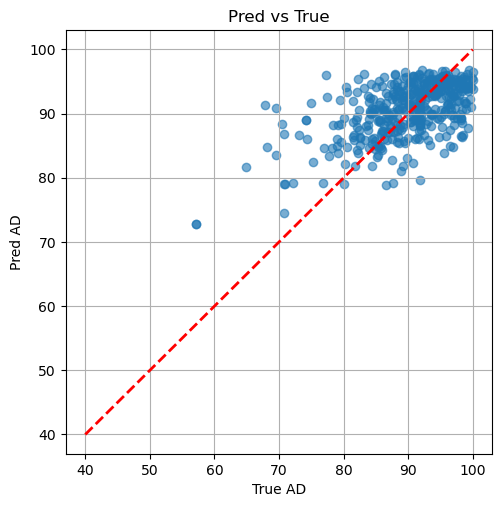

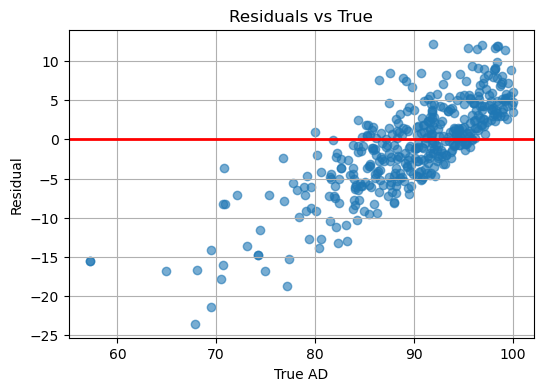

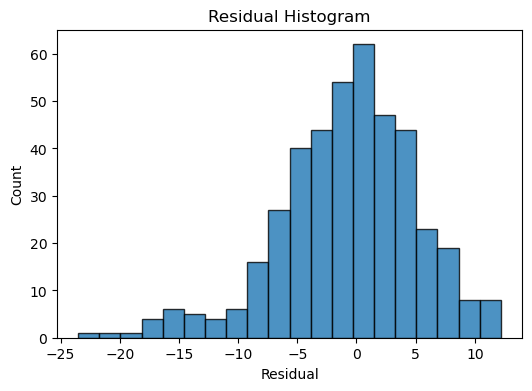

In [38]:
import matplotlib.pyplot as plt

# Pred vs True
plt.figure(figsize=(5.5,5.5))
plt.scatter(y_true, y_hat, alpha=0.6)
plt.plot([40,100],[40,100],'r--',lw=2)  # adjust if min AD differs
plt.xlabel("True AD"); plt.ylabel("Pred AD"); plt.title("Pred vs True"); plt.grid(True); plt.show()

# Residuals
res = y_true - y_hat
plt.figure(figsize=(6,4))
plt.scatter(y_true, res, alpha=0.6)
plt.axhline(0,color='r',lw=2); plt.xlabel("True AD"); plt.ylabel("Residual")
plt.title("Residuals vs True"); plt.grid(True); plt.show()

# Residual distribution
plt.figure(figsize=(6,4))
plt.hist(res, bins=20, edgecolor='k', alpha=0.8)
plt.xlabel("Residual"); plt.ylabel("Count"); plt.title("Residual Histogram"); plt.show()


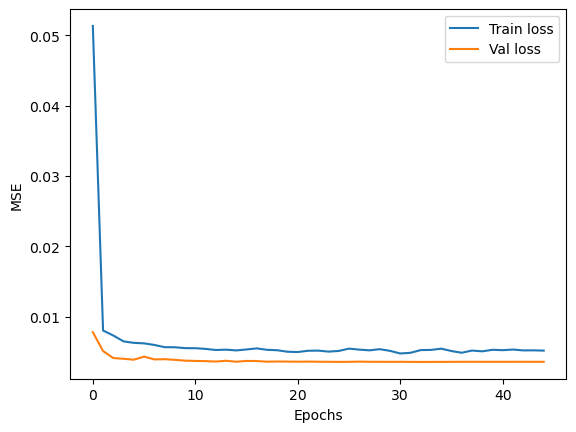

In [34]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()


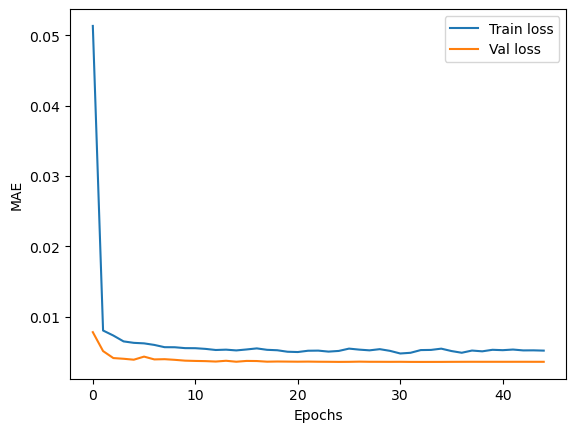

In [35]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()


In [40]:
y_train_scaled = y_train / 100
y_val_scaled   = y_val / 100
y_test_scaled  = y_test / 100

In [41]:
model_complex.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),  # smaller steps
    loss='mse',
    metrics=['mae']
)

es = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,                 # allow more epochs before stopping
    restore_best_weights=True,
    verbose=1
)

lr_sched = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=6,                  # slower decay
    min_lr=1e-6,
    verbose=1
)

history_long = model_complex.fit(
    X_train_s, y_train_scaled,
    validation_data=(X_val_s, y_val_scaled),
    epochs=250,                  # longer training window
    batch_size=32,
    callbacks=[es, lr_sched],
    verbose=1
)


Epoch 1/250
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - loss: 0.0052 - mae: 0.0549 - val_loss: 0.0036 - val_mae: 0.0442 - learning_rate: 5.0000e-04
Epoch 2/250
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - loss: 0.0047 - mae: 0.0514 - val_loss: 0.0035 - val_mae: 0.0436 - learning_rate: 5.0000e-04
Epoch 3/250
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 156ms/step - loss: 0.0048 - mae: 0.0523 - val_loss: 0.0036 - val_mae: 0.0434 - learning_rate: 5.0000e-04
Epoch 4/250
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - loss: 0.0047 - mae: 0.0522 - val_loss: 0.0035 - val_mae: 0.0433 - learning_rate: 5.0000e-04
Epoch 5/250
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - loss: 0.0050 - mae: 0.0528 - val_loss: 0.0036 - val_mae: 0.0436 - learning_rate: 5.0000e-04
Epoch 6/250
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - loss: 0.0053 - mae: 0.0548 - val_loss: 0.0035 - val_mae: 0.0436 - learning_rate: 5.0000e-04
Epoch 7/250
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - loss: 0.0048 - mae: 0.0526 - val_loss: 0.0035 - val_mae: 0.04

In [42]:
results = model_complex.evaluate(X_test_s, y_test_scaled, verbose=0)
print(f"Test MSE (scaled): {results[0]:.6f}")
print(f"Test MAE (scaled): {results[1]:.6f}")


Test MSE (scaled): 0.003399
Test MAE (scaled): 0.043969


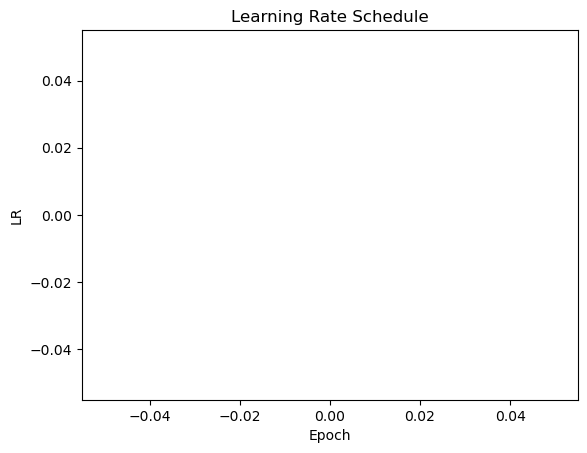

In [44]:
lrs = [lr['lr'] for lr in history_long.history if 'lr' in lr]
plt.plot(lrs)
plt.title("Learning Rate Schedule")
plt.xlabel("Epoch"); plt.ylabel("LR")
plt.show()
